# PR-x-missingness-fraction
6.24.25

Can we make a single precision-recall plot that integrates several curves, each corresponding
to a simulted dataset with a different missingness fraction? 

In [54]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve

# plotting templates
sns.set(context="talk", style="ticks") 
sns.set_palette("tab10")

#### Configs

In [55]:
nruns=128

#### Functions

In [56]:
def bh_adjustment(pvals):
    """
    Performs the Benjamini-Hochberg procedure
    for p-value ADJUSTMENT. So this means we actually 
    return a list of corrected p-values, not just a 
    boolean specifying which p-values to keep per the
    FDR controlled at some threshold. 
    
    Parameters
    ----------
    pvals : np.ndarray, 
        The sorted list of uncorrected p-values. Sorted
        from smallest to largest

    Returns
    -----------
    pvals_adjusted : list, 
        A list of the BH adjusted p-values
    """
    pvals_adjusted = []

    for i in range(0, len(pvals)):
        rank = i + 1
        curr_pval = pvals[i]
        pval_adj = (curr_pval * len(pvals)) / rank
        pvals_adjusted.append(pval_adj)        

    return pvals_adjusted

def get_rank_sum_stats(mat0, mat1):
    """
    Performs a Wilcoxon rank-sum test for every protein, for two experimental conditions. 

    Parameters
    ----------
    mat0, mat1 : np.ndarray, 
        The two input matrices, one for each condition. 

    Returns
    ----------
    pvals : list,
        The (uncorrected) p-values
    rs_stats : list, 
        The rank-sum statistics 
    """
    pvals = []
    rs_stats = []
    
    for i in range(0, mat0.shape[0]):
        stat, pval = stats.ranksums(mat0[i], mat1[i], nan_policy="omit")
        pvals.append(pval)
        rs_stats.append(stat)

    return pvals, rs_stats

#### Read in the Lupine imputed simulated quants matrices 

In [57]:
# Read in our impute matrices 
lupine_00 = pd.read_csv("../results/lupine-quant-simulated-mv-00-p-0075-87958134.csv", index_col=0)
lupine_01 = pd.read_csv("../results/lupine-quant-simulated-mv-01-p-0075-91467916.csv", index_col=0)
lupine_02 = pd.read_csv("../results/lupine-quant-simulated-mv-02-p-0075-17234569.csv", index_col=0)
lupine_04 = pd.read_csv("../results/lupine-quant-simulated-mv-04-p-0075-19798734.csv", index_col=0)
lupine_06 = pd.read_csv("../results/lupine-quant-simulated-mv-06-p-0075-16478973.csv", index_col=0)

# Read in the ground truth dataframe, solely for the purpose of getting the column IDs
gt_df = pd.read_csv("../data/quant-simulated-mv-00-p-0075.csv", index_col=0)

# Read in the list of ground truth DA proteins
da_gt_00 = pd.read_csv("../data/groundtruth-mv-00-p-0075.csv", index_col=0)
da_gt_01 = pd.read_csv("../data/groundtruth-mv-00-p-0075.csv", index_col=0)
da_gt_02 = pd.read_csv("../data/groundtruth-mv-00-p-0075.csv", index_col=0)
da_gt_04 = pd.read_csv("../data/groundtruth-mv-00-p-0075.csv", index_col=0)
da_gt_06 = pd.read_csv("../data/groundtruth-mv-00-p-0075.csv", index_col=0)

lupine_00.columns = gt_df.columns
lupine_01.columns = gt_df.columns
lupine_02.columns = gt_df.columns
lupine_04.columns = gt_df.columns
lupine_06.columns = gt_df.columns

lupine_00.index = gt_df.index
lupine_01.index = gt_df.index
lupine_02.index = gt_df.index
lupine_04.index = gt_df.index
lupine_06.index = gt_df.index

#### Separate out into the two different conditions 

In [58]:
cond0_lupine_00 = np.array(lupine_00.iloc[:, :nruns])
cond1_lupine_00 = np.array(lupine_00.iloc[:, nruns:])

cond0_lupine_01 = np.array(lupine_01.iloc[:, :nruns])
cond1_lupine_01 = np.array(lupine_01.iloc[:, nruns:])

cond0_lupine_02 = np.array(lupine_02.iloc[:, :nruns])
cond1_lupine_02 = np.array(lupine_02.iloc[:, nruns:])

cond0_lupine_04 = np.array(lupine_04.iloc[:, :nruns])
cond1_lupine_04 = np.array(lupine_04.iloc[:, nruns:])

cond0_lupine_06 = np.array(lupine_06.iloc[:, :nruns])
cond1_lupine_06 = np.array(lupine_06.iloc[:, nruns:])

#### Calculate the Wilcoxon rank-sum test statistics 

In [59]:
pvals_lupine_00, _ = get_rank_sum_stats(cond0_lupine_00, cond1_lupine_00)
pvals_lupine_01, _ = get_rank_sum_stats(cond0_lupine_01, cond1_lupine_01)
pvals_lupine_02, _ = get_rank_sum_stats(cond0_lupine_02, cond1_lupine_02)
pvals_lupine_04, _ = get_rank_sum_stats(cond0_lupine_04, cond1_lupine_04)
pvals_lupine_06, _ = get_rank_sum_stats(cond0_lupine_06, cond1_lupine_06)

#### Init a stats dataframe

In [60]:
# Init a stats dataframe 
colnames = ["ENSP","lupine_pval_00", "lupine_pval_01", "lupine_pval_02",
            "lupine_pval_04", "lupine_pval_06"]
stats_df = pd.DataFrame(columns=colnames)
stats_df["ENSP"] = lupine_00.index
stats_df["lupine_pval_00"] = pvals_lupine_00
stats_df["lupine_pval_01"] = pvals_lupine_01
stats_df["lupine_pval_02"] = pvals_lupine_02
stats_df["lupine_pval_04"] = pvals_lupine_04
stats_df["lupine_pval_06"] = pvals_lupine_06

#### Get the ground truth differentially abundant protein IDs 

In [61]:
# For the 0% missingness dataset
upreg_ensp_00 = list(da_gt_00["upreg"])
downreg_ensp_00 = list(da_gt_00["downreg"])
diff_ensp_gt_00 = upreg_ensp_00 + downreg_ensp_00

# For the 10% missingness dataset
upreg_ensp_01 = list(da_gt_01["upreg"])
downreg_ensp_01 = list(da_gt_01["downreg"])
diff_ensp_gt_01 = upreg_ensp_01 + downreg_ensp_01

# For the 20% missingness dataset
upreg_ensp_02 = list(da_gt_02["upreg"])
downreg_ensp_02 = list(da_gt_02["downreg"])
diff_ensp_gt_02 = upreg_ensp_02 + downreg_ensp_02

# For the 40% missingness dataset
upreg_ensp_04 = list(da_gt_04["upreg"])
downreg_ensp_04 = list(da_gt_04["downreg"])
diff_ensp_gt_04 = upreg_ensp_04 + downreg_ensp_04

# For the 60% missingness dataset
upreg_ensp_06 = list(da_gt_06["upreg"])
downreg_ensp_06 = list(da_gt_06["downreg"])
diff_ensp_gt_06 = upreg_ensp_06 + downreg_ensp_06

#### Get binary vectors representing the ground truth differential abundance labels

In [62]:
# For the 0% missingness condition 
gt_labels_00 = [x in diff_ensp_gt_00 for x in stats_df["ENSP"]]
gt_labels_00 = np.array(gt_labels_00)*1

# For the 10% missingness condition 
gt_labels_01 = [x in diff_ensp_gt_01 for x in stats_df["ENSP"]]
gt_labels_01 = np.array(gt_labels_01)*1

# For the 20% missingness condition 
gt_labels_02 = [x in diff_ensp_gt_02 for x in stats_df["ENSP"]]
gt_labels_02 = np.array(gt_labels_02)*1

# For the 40% missingness condition 
gt_labels_04 = [x in diff_ensp_gt_04 for x in stats_df["ENSP"]]
gt_labels_04 = np.array(gt_labels_04)*1

# For the 60% missingness condition 
gt_labels_06 = [x in diff_ensp_gt_06 for x in stats_df["ENSP"]]
gt_labels_06 = np.array(gt_labels_06)*1

#### Get the precision-recall statistics 

In [63]:
# Get the PR stats for Lupine 0% missingness
pvals_00 = stats_df["lupine_pval_00"]
scores_00 = -np.log10(pvals_00)

pr_00, recall_00, _ = precision_recall_curve(y_true=gt_labels_00, y_score=scores_00)
auc_00 = auc(recall_00, pr_00)

# Get the PR stats for Lupine 10% missingness
pvals_01 = stats_df["lupine_pval_01"]
scores_01 = -np.log10(pvals_01)

pr_01, recall_01, _ = precision_recall_curve(y_true=gt_labels_01, y_score=scores_01)
auc_01 = auc(recall_01, pr_01)

# Get the PR stats for Lupine 20% missingness
pvals_02 = stats_df["lupine_pval_02"]
scores_02 = -np.log10(pvals_02)

pr_02, recall_02, _ = precision_recall_curve(y_true=gt_labels_02, y_score=scores_02)
auc_02 = auc(recall_02, pr_02)

# Get the PR stats for Lupine 40% missingness
pvals_04 = stats_df["lupine_pval_04"]
scores_04 = -np.log10(pvals_04)

pr_04, recall_04, _ = precision_recall_curve(y_true=gt_labels_04, y_score=scores_04)
auc_04 = auc(recall_04, pr_04)

# Get the PR stats for Lupine 60% missingness
pvals_06 = stats_df["lupine_pval_06"]
scores_06 = -np.log10(pvals_06)

pr_06, recall_06, _ = precision_recall_curve(y_true=gt_labels_06, y_score=scores_06)
auc_06 = auc(recall_06, pr_06)

#### Plot! 

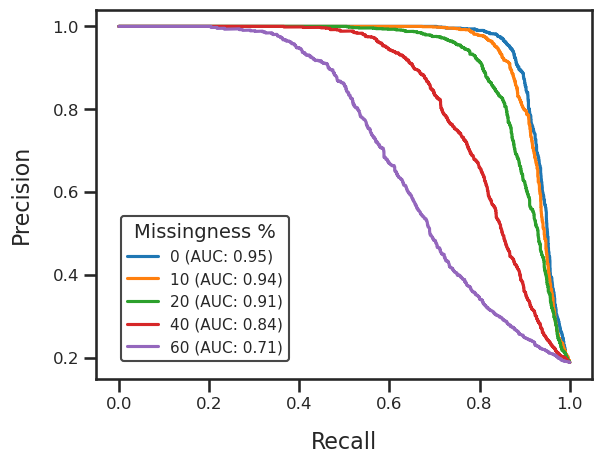

In [66]:
plt.figure()

plt.plot(recall_00, pr_00, label="0 (AUC: " + str(np.around(auc_00, 2)) + ")")
plt.plot(recall_01, pr_01, label="10 (AUC: " + str(np.around(auc_01, 2)) + ")")
plt.plot(recall_02, pr_02, label="20 (AUC: " + str(np.around(auc_02, 2)) + ")")
plt.plot(recall_04, pr_04, label="40 (AUC: " + str(np.around(auc_04, 2)) + ")")
plt.plot(recall_06, pr_06, label="60 (AUC: " + str(np.around(auc_06, 2)) + ")")

plt.xlabel("Recall", size=16, labelpad=14)
plt.ylabel("Precision", size=16, labelpad=14)
plt.legend(title="Missingness %", edgecolor="k", title_fontsize=14, 
           prop={'size': 11}, loc=(0.05, 0.05))

plt.tick_params(axis='both', which='major', labelsize=12)
plt.locator_params(axis='y', min_n_ticks=4, nbins=6, tight="true")

#plt.show()
#plt.savefig("../figures/precision-recall-curves-protwise-simulation-vary-MV-p0075.png", dpi=300, bbox_inches="tight")
#plt.savefig("../figures/precision-recall-curves-protwise-simulation-vary-MV-p0075.pdf", bbox_inches="tight")